**Angie Carolina Joya Duarte - 2322609**  

**Sheila Marcela Valencia Chito - 2243011**

## 1) Preparar el dataset

Importar librerías

In [24]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import math

Definir las semillas

In [25]:
semilla = 42
random.seed(semilla)
np.random.seed(semilla)

Leer dataset seleccionado: ibm.us.csv

In [26]:
path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0


### a) Graficar el promedio

In [27]:
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset["Date"] = pd.to_datetime(dataset["Date"])
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt,promedioDia
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0,6.37540
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0,6.36705
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0,6.36290
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0,6.25845
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0,6.12070


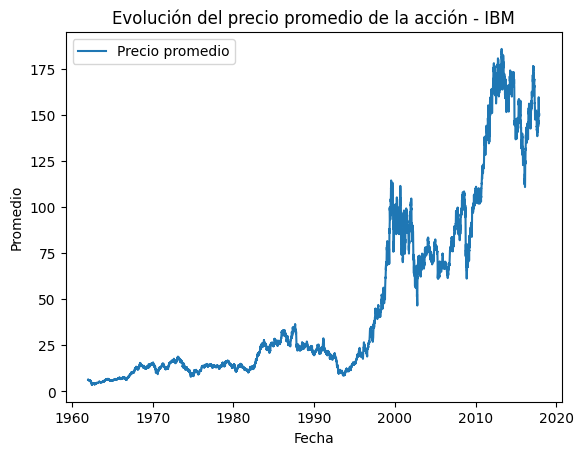

In [28]:
plt.plot(dataset["Date"], dataset["promedioDia"], label = "Precio promedio")
plt.title("Evolución del precio promedio de la acción - IBM")
plt.xlabel("Fecha")
plt.ylabel("Promedio")
plt.legend()
plt.show()

### b) Dividir los datos

In [29]:
#70% train, 15% validation, 15% test
n = len(dataset)

# train = dataset[:int(n*0.7)].copy()
# validation = dataset[int(n*0.7):int(n*0.85)].copy()
# test = dataset[int(n*0.85):].copy()

train = dataset[:int(n*0.7)][["promedioDia"]].to_numpy()
validation = dataset[int(n*0.7):int(n*0.85)][["promedioDia"]].to_numpy()
test = dataset[int(n*0.85):][["promedioDia"]].to_numpy()

print("Conjunto de entrenamiento: ",train[:5])
print("Conjunto de validación: ",validation[:5])
print("Conjunto de prueba: ",test[:5])

Conjunto de entrenamiento:  [[6.3754 ]
 [6.36705]
 [6.3629 ]
 [6.25845]
 [6.1207 ]]
Conjunto de validación:  [[96.151 ]
 [96.9425]
 [94.351 ]
 [94.384 ]
 [96.2135]]
Conjunto de prueba:  [[87.6125]
 [88.094 ]
 [85.8565]
 [84.6285]
 [84.332 ]]


### c) Normalizar los datos

Normalizar los datos

In [30]:
#Hallar la media y desviación del entrenamiento
media = train.mean()
desvest  = train.std()

#Normalizar los 3 subconjuntos respecto a los valores calculados
train = (train - media) / desvest
validation   = (validation   - media) / desvest
test  = (test  - media) / desvest

Creación de ventanas

In [31]:
#Ventanas de 30 días con muestras diarias
sampling_rate = 1
sequence_length = 15
delay = 1 
batch_size = 256

## 2) Modelo LSTM 

Perparar el dataset de entrenamiento de acuerdo a la ventana de tiempo

In [ ]:
train2D = train.reshape(-1, 1)

datasetTrain = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

[[-0.77800862]
 [-0.77844315]
 [-0.77865911]
 ...
 [ 3.74323105]
 [ 3.70682949]
 [ 3.81387452]]
